# Phase 1 — Shallow ingestion

Per ROADMAP.md Phase 1/2, this deliberately does **not** parse full documents. Per PDF it extracts:

- **front** = abstract + introduction, **back** = summary + conclusion (nothing else)
- figures and tables that fall on those pages
- metadata: `topic` (the paper's own heading, parsed from page 1), `category` (parent folder =
  arXiv category, never parsed), `num_pages`, `authors` (dict)

Output is a flat `list[Document]` of chunks ready for embedding, carrying the ROADMAP §Phase 2 metadata
schema: `arxiv_id`, `category`, `topic`, `section`, `modality` (`text|figure|table`), `page`, `figure_ref`.

**`category` vs `topic`** — these do different jobs and must not be conflated. `category` is the
directory name: a closed set of five values, exact, free ground truth, and the thing retrieval filters on
and the router is scored against. `topic` is the paper's title: free text, one value per document, useful
for citations and display but useless as a filter key.

### Libraries

`PyMuPDFLoader` handles page text + PDF metadata, `RecursiveCharacterTextSplitter` handles chunking.

Raw `fitz` (PyMuPDF) is still imported for jobs no loader exposes: pulling embedded image bytes, detecting
tables, and reading per-span font sizes for title detection. `PyMuPDFLoader(extract_images=True)` runs OCR
over images and folds the result into the page *text* — that throws the picture away, and we need the
actual bytes to send to the VLM.

### Requires

```
uv add pymupdf
```

In [1]:
import base64
import concurrent.futures
import json
import os
import re
import threading
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import fitz  # pymupdf — embedded-image bytes, table detection, per-span font sizes
from dotenv import load_dotenv
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

try:  # langchain >=1.0 moved the splitters into their own package
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ImportError:
    from langchain.text_splitter import RecursiveCharacterTextSplitter

# --- pymupdf-layout -----------------------------------------------------------------
# Replaces the built-in line/whitespace table detector with a trained layout model, and does
# change find_tables() results — pages that returned nothing can return real tables. This is the
# same engine pymupdf4llm silently activates on import.
#
#   uv add pymupdf-layout
#
# LICENSE: dual-licensed Polyform Noncommercial / Artifex commercial. Fine for a capstone, but it
# is a non-commercial dependency — put it in the README rather than discovering it later.
LAYOUT_ACTIVE = False
try:
    import pymupdf.layout  # noqa: F401  (import alone may be enough; activate() if exposed)

    if hasattr(pymupdf.layout, "activate"):
        pymupdf.layout.activate()
    LAYOUT_ACTIVE = True
except Exception as exc:  # not installed, or the API moved — degrade, never break the notebook
    print(f"[layout] pymupdf-layout inactive ({type(exc).__name__}: {exc}); using built-in detector")

# --- MuPDF thread safety -------------------------------------------------------------
# MuPDF gives no thread-safety guarantees, and it shows: the same PDF returned 0 tables when
# processed alone and 2 tables when processed inside the batch ThreadPoolExecutor. Every fitz
# call is therefore serialised behind this lock. The cost is near zero — PDF parsing is
# milliseconds per document, while the VLM round trips it runs alongside take seconds, and
# those stay fully parallel because captioning touches no fitz object.
PDF_LOCK = threading.Lock()

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_key")

PROJECT_ROOT = Path.cwd().parent
PAPERS_DIR = PROJECT_ROOT / "arxiv_papers"
print(PAPERS_DIR, PAPERS_DIR.exists(), "| layout engine active:", LAYOUT_ACTIVE)

C:\Users\goyal\AppData\Local\Temp\ipykernel_27628\2754686173.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader
d:\.tutorials\agentic-rag-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


d:\.tutorials\agentic-rag-capstone\arxiv_papers True | layout engine active: True


## Config

Chunking here is the **fixed-window with overlap** arm from ROADMAP §Phase 2. The section-aware arm
is the other half of that comparison — the `section` metadata field below is what makes it possible later.

In [2]:
# TODO: read from config/pricing.yaml once this model ID is verified (ROADMAP Phase 0 open item)
VLM_MODEL_ID = "gemini-3.1-flash-lite"

CHUNK_SIZE = 1000
CHUNK_OVERLAP = 150

# Peak in-flight VLM requests during a batch run = BATCH max_workers * MAX_CAPTION_WORKERS.
# Keep the product under your provider's rate limit.
MAX_CAPTION_WORKERS = 4

MIN_IMAGE_BYTES = 3000      # below this is almost always a logo / icon / watermark
MAX_HEADING_LINE_LEN = 60   # headings are short standalone lines; longer matches are body text

# --- word spacing ---
# LaTeX justifies a line by positioning each word individually instead of emitting space
# characters, so PyMuPDF returns one span per word with no whitespace between them. Concatenating
# those spans directly produced "Cansupply-chainAImovebeyond". A horizontal gap wider than this
# fraction of the font size means the words were visually separated, so a space belongs there.
SPAN_SPACE_GAP_RATIO = 0.15

# --- column layout ---
# A block crossing the page midline by more than this margin (pt) is full-width: a title, an
# abstract, a spanning figure. Everything else belongs to the left or right column.
COLUMN_GUTTER_MARGIN = 12.0
# Treat a page as two-column only if this fraction of its blocks sit cleanly inside one column.
COLUMN_MIN_FRACTION = 0.6

# --- heading detection by font ---
# A line is a heading if it is set larger than body text, or is bold and short. 0.6pt is enough
# to separate a 12pt section heading from 11pt body while ignoring sub/superscript jitter.
HEADING_FONT_DELTA = 0.6
# Two headings within this many pt are the same level. A section heading ends the section; a
# smaller subsection heading ("2.1 Background") does not.
HEADING_LEVEL_TOLERANCE = 0.4
# Some templates set the section number on its own line ("1" / "Introduction"). Left alone, the
# bare number is what the section-boundary patterns see, and every match fails.
ORPHAN_NUMBER = re.compile(r"^\d+(\.\d+)*\.?$")

# --- LLM section fallback ---
# Used only when the font/regex rules find no front span — about 5% of the corpus. The IEEE
# template is the canonical case: its headings are small caps ("I. INTRODUCTION" renders as a
# 10pt "I" plus an 8pt "NTRODUCTION"), so the line is neither larger than body text nor bold and
# is_heading() sees nothing at all.
#
# The catalogue therefore offers every SHORT line, not just detected headings — otherwise there
# would be nothing to show the model on exactly the documents that need it. The model returns
# indices into that catalogue, never text, so it cannot invent content: the worst it can do is
# pick a wrong line, and every index is validated before use.
LLM_CANDIDATE_MAX_LINES = 150
LLM_SECTION_SYSTEM = (
    "You locate section boundaries in a research paper. You are given candidate lines as "
    "'index: text'. Reply with JSON only, no prose, no code fence:\n"
    '{"intro_start": int|null, "intro_end": int|null, '
    '"conclusion_start": int|null, "conclusion_end": int|null}\n'
    "intro_start  = the Abstract or Introduction heading line.\n"
    "intro_end    = the heading that begins the NEXT section after the Introduction "
    "Use bookmarks or contents if available. The span is [intro_start, intro_end).\n"
    "conclusion_start = the Conclusion / Summary / Discussion-and-Conclusion heading.\n"
    "conclusion_end   = the heading that follows it (References, Acknowledgments, Appendix).\n"
    "Every value must be an index from the candidate list, or null if that section is absent."
)

# --- section boundaries ---
FRONT_START = re.compile(r"^\s*(\d+\.?\s*)?(abstract|introduction)\b", re.IGNORECASE)
# Headings that appear between the abstract and the end of the intro must not terminate the span.
FRONT_CONTINUE = re.compile(
    r"^\s*(\d+\.?\s*)?(abstract|introduction|keywords?|index terms|ccs concepts|acm reference format)\b",
    re.IGNORECASE,
)
BACK_START = re.compile(
    r"^\s*(\d+\.?\s*)?(conclusions?|summary|concluding remarks|discussion and conclusions?)\b",
    re.IGNORECASE,
)

# --- title (topic) detection ---
TITLE_SEARCH_TOP_FRACTION = 0.5  # titles live in the top half of page 1
TITLE_FONT_TOLERANCE = 0.5       # spans within this many pt of the max count as title text
TITLE_MIN_LEN = 8
TITLE_MAX_LEN = 300
ARXIV_STAMP = re.compile(r"^\s*arxiv[:\s]", re.IGNORECASE)
# ARXIV_STAMP is anchored and is matched against a whole line during title detection, where the
# stamp stands alone. _is_marginalia needs the same stamp found ANYWHERE in a line: rotated 90
# degrees down the left margin, it lands mid-document once content order is flattened, which is
# how it once truncated the front span (PHASE1_NOTES 3.5).
#
# Deliberately narrow. An unanchored bare /arxiv/ would also delete real body sentences like
# "we collected these papers from arXiv", so the identifier itself must be present. Both the
# modern (2607.28503v1) and legacy (hep-th/9901001) ID formats are accepted.
ARXIV_STAMP_ANY = re.compile(
    r"arxiv:\s*(\d{4}\.\d{4,5}(v\d+)?|[a-z-]+(\.[a-z]{2})?/\d{7})", re.IGNORECASE
)
# Horizontal text has dir == (1, 0); the rotated stamp is (0, +/-1). Anything meaningfully off
# the horizontal axis is marginalia, not content.
HORIZONTAL_DIR_TOLERANCE = 0.1
# LaTeX toolchains often leave a filename or placeholder in the PDF /Title field.
JUNK_TITLES = re.compile(r"^(untitled|main|paper|manuscript|draft|document|ms|article)$", re.IGNORECASE)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)

llm = ChatGoogleGenerativeAI(model=VLM_MODEL_ID)

## Assumptions

These will break on some fraction of the corpus. Phase 1 exists to find out which fraction.

1. **Section detection is a heading-text heuristic**, not layout-aware parsing (explicitly cut, ROADMAP §7).
   It looks for short standalone lines matching `Abstract` / `Introduction` / `Conclusion` / `Summary`.
   Papers with unnumbered headings, image-rendered headings, non-English headings, or two-column layouts
   where a heading line gets split will miss — those fall back to *first 3 pages / last 2 pages*.
   `sections_found` records which path was taken; **track that rate across the 100-doc slice**, it is a
   real ingestion-failure statistic and feeds the Phase 10 taxonomy.
2. **Authors come from the PDF `/Author` field** (surfaced by `PyMuPDFLoader` as `metadata["author"]`),
   split on commas / semicolons / `" and "`. That field is often missing, truncated, or one garbled string
   on arXiv-generated PDFs. The dict is keyed by **1-indexed author order**, since order is the only thing
   guaranteed unique when the field exists at all. No affiliation extraction — that needs layout-awareness.
3. **`category` is the parent directory name** (`arxiv_papers/<category>/`) and is never parsed from the
   paper. That is the free ground-truth label from ROADMAP §1 — it is what the router is evaluated against
   and what retrieval filters on, so it must stay exact and low-cardinality.
4. **`topic` is the paper's own heading**, parsed from page 1 by taking the **largest font size in the top
   half of the page**. Font size beats position here: a preprint notice or conference banner often sits
   above the title, but is set smaller. The arXiv ID watermark down the left margin is filtered explicitly.
   Falls back to the PDF `/Title` field, then to the first substantial line. `topic_source` records which
   path ran — **watch its distribution the same way you watch `sections_found`.** Known failure: a paper
   whose title is typeset at the same size as an author block or a large section heading will over-capture.
   `topic` is descriptive metadata for citations and display; **do not filter retrieval on it** — it is
   free text with no controlled vocabulary. That is what `category` is for.
5. **Table extraction uses PyMuPDF `find_tables()`** — a heuristic line/whitespace detector, not a layout
   model. Tables rendered as raster images get captured as *images* instead and captioned by the VLM.
6. **The conclusion span ends** at the first `References` / `Bibliography` / `Acknowledgments`, else EOF.
7. **Images under 3KB are dropped** as logos/icons. A genuinely tiny real figure would be lost.
8. **Figures are indexed by their VLM caption**, not by the paper's own caption text (`Figure 3: ...`),
   which stays in the body text and is chunked separately. The two are not linked yet — a known gap to
   revisit if figure-requiring questions underperform in the sliced metrics (§3⑥).

## Data model

In [3]:
@dataclass
class PageSpan:
    start_page: int  # 0-indexed, inclusive
    end_page: int    # 0-indexed, inclusive


@dataclass
class ExtractedImage:
    image_id: str
    page: int
    section: str  # "abstract_intro" | "conclusion"
    ext: str
    image_bytes: bytes
    caption: Optional[str] = None


@dataclass
class DocumentExtraction:
    arxiv_id: str
    topic: str                    # the paper's own heading, parsed from page 1
    topic_source: str             # "layout" | "pdf_field" | "first_line" | "none"
    category: str                 # parent directory = arXiv category, ground truth
    num_pages: int
    authors: dict[int, str]
    section_source: str           # "headings" | "llm" | "page_fallback"
    chunks: list[Document]        # everything, ready to embed
    images: list[ExtractedImage]  # raw bytes kept out of chunk metadata; for the generator + inspection
    tables: list[dict]            # kept alongside the chunks so the markdown can be eyeballed

    @property
    def sections_found(self) -> bool:
        """True when the span came from a real boundary — rules or LLM — rather than a page guess."""
        return self.section_source != "page_fallback"

    def summary(self) -> str:
        by_modality: dict[str, int] = {}
        for c in self.chunks:
            m = c.metadata["modality"]
            by_modality[m] = by_modality.get(m, 0) + 1
        return (
            f"{self.arxiv_id} <{self.category}> {self.num_pages}p "
            f"authors={len(self.authors)} section_source={self.section_source} "
            f"topic_source={self.topic_source} chunks={len(self.chunks)} {by_modality}\n"
            f"    topic: {self.topic[:110] or '(none)'}"
        )

## Metadata

`PyMuPDFLoader` copies the PDF info dict onto every page `Document`, so page 0's metadata is enough.

In [4]:
def parse_authors(raw: str) -> dict[int, str]:
    """Split the /Author string into a 1-indexed {order: name} dict. See assumption 2."""
    if not raw or not raw.strip():
        return {}
    normalized = re.sub(r"\s+and\s+", ",", raw, flags=re.IGNORECASE).replace(";", ",")
    names = [n.strip() for n in normalized.split(",") if n.strip()]
    return {i + 1: name for i, name in enumerate(names)}


def _plausible_title(text: str, arxiv_id: str) -> bool:
    """Reject the usual /Title garbage: filenames, placeholders, the arXiv stamp."""
    t = (text or "").strip()
    if not (TITLE_MIN_LEN <= len(t) <= TITLE_MAX_LEN):
        return False
    if JUNK_TITLES.match(t) or ARXIV_STAMP.match(t):
        return False
    if t.lower().endswith((".pdf", ".tex", ".dvi", ".ps")):
        return False
    return arxiv_id.lower() not in t.lower()


def title_from_layout(pdf_path: Path) -> str:
    """Largest-font text in the top half of page 1 — that is the title in essentially every
    paper template. Keying on font size rather than position means it still works when a
    conference banner or preprint notice sits above the title."""
    with fitz.open(pdf_path) as doc:
        if doc.page_count == 0:
            return ""
        page = doc[0]
        cutoff = page.rect.height * TITLE_SEARCH_TOP_FRACTION
        spans: list[tuple[float, float, str]] = []  # (font_size, y, text)
        for block in page.get_text("dict")["blocks"]:
            if block.get("type") != 0:  # 0 = text, 1 = image
                continue
            for line in block["lines"]:
                for span in line["spans"]:
                    text = span["text"].strip()
                    y = span["bbox"][1]
                    if not text or y > cutoff or ARXIV_STAMP.match(text):
                        continue
                    spans.append((round(span["size"], 1), y, text))

    if not spans:
        return ""

    max_size = max(s[0] for s in spans)
    # A title wrapping onto a second line renders as several spans at the same size — keep them all.
    title_spans = sorted(
        (s for s in spans if s[0] >= max_size - TITLE_FONT_TOLERANCE), key=lambda s: s[1]
    )
    return re.sub(r"\s+", " ", " ".join(t for _, _, t in title_spans)).strip()


def extract_title(pages: list[Document], pdf_path: Path) -> tuple[str, str]:
    """The paper's own heading -> (title, source). `source` records which path produced it,
    so its fallback rate is measurable the same way `sections_found` is."""
    arxiv_id = pdf_path.stem
    pdf_field = (pages[0].metadata.get("title", "") if pages else "") or ""
    layout = title_from_layout(pdf_path)

    # Layout first: the /Title field is more often a build artifact than the real heading.
    if _plausible_title(layout, arxiv_id):
        return layout, "layout"
    if _plausible_title(pdf_field, arxiv_id):
        return pdf_field.strip(), "pdf_field"

    # Last resort: first substantial line of page 1.
    for line in (pages[0].page_content.splitlines() if pages else []):
        if _plausible_title(line, arxiv_id):
            return line.strip(), "first_line"
    return "", "none"


def extract_metadata(pages: list[Document], pdf_path: Path) -> dict:
    head = pages[0].metadata if pages else {}
    topic, topic_source = extract_title(pages, pdf_path)
    return {
        "arxiv_id": pdf_path.stem,
        "topic": topic,                     # the paper's own heading, parsed from the PDF
        "topic_source": topic_source,
        "category": pdf_path.parent.name,   # arXiv category — ground-truth label, never parsed
        "num_pages": head.get("total_pages", len(pages)),
        "authors": parse_authors(head.get("author", "") or ""),
    }

## Section detection

Cuts at **heading lines**, not page boundaries. The previous page-level version took whole pages,
so the front span dragged in whatever followed the introduction on its last page.

Headings are found by font: a short line set larger than body text, or bolded. Body size is the
character-weighted most common size in the document, so it needs no per-template configuration.

Font size also gives heading *level* for free, which is what makes the cut correct: a span ends at
the next heading **the same size or larger**. A smaller subsection heading (`2.1 Background`) sits
inside the intro and does not terminate it; the next real section (`2 Related Work`) does.

Needs raw `fitz` — `PyMuPDFLoader` returns plain text with the font information already discarded.

In [5]:
@dataclass
class Line:
    page: int
    text: str
    size: float  # largest span size on the line
    bold: bool


def line_text(spans: list[dict]) -> str:
    """Join a line's spans, restoring the spaces the PDF never stored.

    LaTeX justifies text by placing each word at an explicit x offset rather than writing space
    characters, so the spans come back as ["Can", "supply-chain", "AI", "move"] with no
    whitespace. Concatenating them gives "Cansupply-chainAImove", which would wreck the
    embeddings — a run-together blob matches no normally-worded query.

    A space is inserted where consecutive spans are visually separated: gap wider than a fraction
    of the font size. Spans that abut (a font switch mid-word, an italic term, a ligature) stay
    joined, so "SCOPE" does not become "S COPE".
    """
    parts: list[str] = []
    previous: Optional[dict] = None
    for span in spans:
        text = span["text"]
        if previous is not None and text and not text[0].isspace():
            gap = span["bbox"][0] - previous["bbox"][2]
            threshold = SPAN_SPACE_GAP_RATIO * max(span["size"], previous["size"])
            if gap > threshold and parts and not parts[-1].endswith(" "):
                parts.append(" ")
        parts.append(text)
        previous = span
    return re.sub(r"\s+", " ", "".join(parts)).strip()


def _is_marginalia(line_dict: dict, text: str) -> bool:
    """The arXiv stamp down the left margin of page 1, and anything else set rotated."""
    if ARXIV_STAMP_ANY.search(text):
        return True
    dx, dy = line_dict.get("dir", (1.0, 0.0))
    return abs(dy) > HORIZONTAL_DIR_TOLERANCE or dx < 1 - HORIZONTAL_DIR_TOLERANCE


def blocks_in_reading_order(page) -> tuple[list[dict], bool]:
    """Text blocks ordered as a human reads them, returning (blocks, is_two_column).

    PDF content order is not reading order. On a two-column paper the stream frequently
    alternates between columns, which interleaves left and right column text mid-sentence and
    scrambles the heading sequence the section cuts depend on.

    Full-width blocks (title, abstract, spanning figures) act as horizontal rules: they split
    the page into bands, and within each band the left column is read fully before the right.
    """
    blocks = [b for b in page.get_text("dict")["blocks"] if b.get("type") == 0]
    if not blocks:
        return [], False

    mid = page.rect.width / 2
    full_width = [
        b for b in blocks
        if b["bbox"][0] < mid - COLUMN_GUTTER_MARGIN and b["bbox"][2] > mid + COLUMN_GUTTER_MARGIN
    ]
    columned = [b for b in blocks if b not in full_width]

    if len(columned) < len(blocks) * COLUMN_MIN_FRACTION:
        return sorted(blocks, key=lambda b: (b["bbox"][1], b["bbox"][0])), False

    anchors = sorted(full_width, key=lambda b: b["bbox"][1])
    ordered: list[dict] = []
    band_top = float("-inf")

    for anchor in anchors + [None]:
        band_bottom = anchor["bbox"][1] if anchor is not None else float("inf")
        band = [b for b in columned if band_top <= b["bbox"][1] < band_bottom]
        left = sorted((b for b in band if b["bbox"][0] < mid), key=lambda b: b["bbox"][1])
        right = sorted((b for b in band if b["bbox"][0] >= mid), key=lambda b: b["bbox"][1])
        ordered.extend(left + right)
        if anchor is not None:
            ordered.append(anchor)
            band_top = band_bottom

    return ordered, True


def _merge_orphan_numbers(lines: list[Line]) -> list[Line]:
    """Rejoin a section number typeset on its own line with the heading that follows.

    Some templates emit "1" and "Introduction" as separate lines. The boundary patterns then
    match neither, and the front span was being cut at the bare "1" — dropping the entire
    introduction while still reporting a successful parse.
    """
    merged: list[Line] = []
    i = 0
    while i < len(lines):
        current = lines[i]
        nxt = lines[i + 1] if i + 1 < len(lines) else None
        if (
            nxt is not None
            and ORPHAN_NUMBER.match(current.text)
            and nxt.page == current.page
            and abs(nxt.size - current.size) <= HEADING_LEVEL_TOLERANCE
        ):
            merged.append(
                Line(current.page, f"{current.text} {nxt.text}",
                     max(current.size, nxt.size), current.bold or nxt.bold)
            )
            i += 2
            continue
        merged.append(current)
        i += 1
    return merged


def document_lines(pdf_path: Path) -> list[Line]:
    """Every text line in the document with its font size, in reading order."""
    lines: list[Line] = []
    with fitz.open(pdf_path) as doc:
        for page_num, page in enumerate(doc):
            ordered, _ = blocks_in_reading_order(page)
            for block in ordered:
                for ln in block["lines"]:
                    # Every span goes to line_text (whitespace-only spans are real spaces);
                    # only the visible ones vote on font size and weight.
                    visible = [s for s in ln["spans"] if s["text"].strip()]
                    if not visible:
                        continue
                    text = line_text(ln["spans"])
                    if not text or _is_marginalia(ln, text):
                        continue
                    lines.append(
                        Line(
                            page=page_num,
                            text=text,
                            size=max(round(s["size"], 1) for s in visible),
                            bold=any("bold" in s["font"].lower() for s in visible),
                        )
                    )
    return _merge_orphan_numbers(lines)


def document_toc(pdf_path: Path) -> list[tuple[int, str]]:
    """The PDF outline as (level, title), or [] when the file has no bookmarks."""
    try:
        with fitz.open(pdf_path) as doc:
            return [(entry[0], entry[1]) for entry in doc.get_toc(simple=True)]
    except Exception as exc:
        print(f"[toc] get_toc FAILED {Path(pdf_path).name}: {type(exc).__name__}: {exc}")
        return []


def body_font_size(lines: list[Line]) -> float:
    """The most common font size weighted by character count — i.e. the size of body text."""
    counts: dict[float, int] = {}
    for ln in lines:
        counts[ln.size] = counts.get(ln.size, 0) + len(ln.text)
    return max(counts, key=counts.get) if counts else 10.0


def is_heading(line: Line, body_size: float) -> bool:
    """Headings are short, and either set larger than body text or bolded."""
    if len(line.text) > MAX_HEADING_LINE_LEN:
        return False
    return line.size >= body_size + HEADING_FONT_DELTA or (line.bold and line.size >= body_size)


def _section_bounds(
    lines: list[Line],
    headings: list[int],
    body_size: float,
    start_pattern: re.Pattern,
    continue_pattern: Optional[re.Pattern] = None,
) -> Optional[tuple[int, int]]:
    """Line indices [start, end) from the heading matching `start_pattern` to the next heading
    at the same level or larger. A smaller subsection heading does not terminate the span; the
    level rises as the span absorbs continuation headings (Abstract -> Introduction)."""
    for pos, idx in enumerate(headings):
        if not start_pattern.match(lines[idx].text):
            continue
        level = lines[idx].size
        for next_idx in headings[pos + 1:]:
            nxt = lines[next_idx]
            if nxt.size < level - HEADING_LEVEL_TOLERANCE:
                continue
            if continue_pattern and continue_pattern.match(nxt.text):
                level = max(level, nxt.size)
                continue
            return idx, next_idx
        return idx, len(lines)
    return None


# --- strategy 1: the PDF outline (bookmarks) -------------------------------------------

def _normalize_heading(text: str) -> str:
    """Strip section numbering and punctuation so a TOC title can be matched to a rendered line.

    'I. INTRODUCTION', '1 Introduction' and 'Introduction' all normalise to 'introduction' —
    which is the point: the outline stores the logical title while the page may render it in
    small caps, with Roman numerals, or with the number on a separate line.
    """
    stripped = re.sub(r"^\s*([IVXLCDM]+|\d+(\.\d+)*|[A-Z])[.)]?\s+", "", text.strip(), flags=re.IGNORECASE)
    return re.sub(r"[^a-z0-9 ]", "", stripped.lower()).strip()


def toc_section_bounds(
    lines: list[Line], toc: list[tuple[int, str]]
) -> tuple[Optional[tuple[int, int]], Optional[tuple[int, int]]]:
    """Locate the front and back spans using the PDF outline.

    Only top-level entries are considered, so subsections cannot terminate a span. Titles are
    matched forward through the line list — each match starts searching after the previous one —
    so a title that also appears in the body (a Related Work sentence naming 'Introduction')
    cannot pull a boundary backwards.

    Returns (front, back); either may be None if the outline lacks that section.
    """
    top_level = [(lvl, title) for lvl, title in toc if lvl == 1]
    if not top_level:
        return None, None

    # Anchor each outline title to the line that renders it.
    anchors: list[tuple[int, str]] = []
    cursor = 0
    for _, title in top_level:
        target = _normalize_heading(title)
        if not target:
            continue
        for i in range(cursor, len(lines)):
            candidate = _normalize_heading(lines[i].text)
            if candidate and (candidate == target or target.startswith(candidate)
                              or candidate.startswith(target)):
                anchors.append((i, target))
                cursor = i + 1
                break

    if not anchors:
        return None, None

    def span_for(pattern: re.Pattern) -> Optional[tuple[int, int]]:
        for pos, (idx, target) in enumerate(anchors):
            if not pattern.match(target):
                continue
            end = anchors[pos + 1][0] if pos + 1 < len(anchors) else len(lines)
            # Abstract is rarely bookmarked — extend backwards if it is right above the intro.
            start = idx
            for back in range(idx - 1, max(idx - 40, -1), -1):
                if _normalize_heading(lines[back].text) == "abstract":
                    start = back
                    break
            return start, end
        return None

    return span_for(FRONT_START), span_for(BACK_START)


# --- strategy 3: the LLM ---------------------------------------------------------------

def candidate_lines(lines: list[Line]) -> list[int]:
    """Indices of lines short enough to plausibly be a heading — font ignored on purpose.
    is_heading() is exactly what has already failed by the time this runs."""
    return [i for i, ln in enumerate(lines) if len(ln.text) <= MAX_HEADING_LINE_LEN]


def _valid_index(value, allowed: set[int], lines: list[Line]) -> Optional[int]:
    """An index the model returned is usable only if it is an integer we actually offered."""
    if isinstance(value, bool) or not isinstance(value, int):
        return None
    if value in allowed:
        return value
    return len(lines) if value == len(lines) else None


def llm_section_bounds(
    lines: list[Line], llm, arxiv_id: str = ""
) -> tuple[Optional[tuple[int, int]], Optional[tuple[int, int]]]:
    """Ask the model which candidate lines open and close each span. Everything it returns is
    validated against the candidate list, so a bad answer degrades to the page-count fallback
    rather than producing a plausible-looking wrong span."""
    if llm is None:
        return None, None

    candidates = candidate_lines(lines)[:LLM_CANDIDATE_MAX_LINES]
    if not candidates:
        return None, None
    allowed = set(candidates)
    catalog = "\n".join(f"{i}: {lines[i].text}" for i in candidates)

    try:
        raw = message_text(llm.invoke([HumanMessage(content=f"{LLM_SECTION_SYSTEM}\n\n{catalog}")]))
        match = re.search(r"\{.*\}", raw, re.S)  # models like to wrap JSON in prose or fences
        if not match:
            print(f"[sections] LLM returned no JSON for {arxiv_id}: {raw[:120]!r}")
            return None, None
        data = json.loads(match.group())
    except Exception as exc:
        print(f"[sections] LLM fallback FAILED {arxiv_id}: {type(exc).__name__}: {exc}")
        return None, None

    def span(start_key: str, end_key: str) -> Optional[tuple[int, int]]:
        start = _valid_index(data.get(start_key), allowed, lines)
        if start is None:
            return None
        end = _valid_index(data.get(end_key), allowed, lines)
        if end is None or end <= start:
            end = len(lines)
        return start, end

    return span("intro_start", "intro_end"), span("conclusion_start", "conclusion_end")


# --- assembly --------------------------------------------------------------------------

def resolve_sections(
    lines: list[Line],
    toc: Optional[list[tuple[int, str]]] = None,
    llm=None,
    arxiv_id: str = "",
) -> tuple[dict[str, str], dict[str, PageSpan], str]:
    """Four strategies, cheapest and most reliable first:

        toc           the PDF outline — the author's own section list, exact titles
        headings      font-size heuristics over the rendered lines
        llm           model picks boundaries from a catalogue of short lines
        page_fallback first 3 pages / last 2 pages

    Returns (texts, page_spans, section_source). section_source rides on every chunk so Phase 4
    can slice retrieval metrics by how the document was parsed.

    Takes parsed lines rather than a path so the caller can hold PDF_LOCK during parsing and
    release it before the network call this may make.
    """
    if not lines:
        return {"abstract_intro": "", "conclusion": ""}, {}, "page_fallback"

    front = back = None
    source = "page_fallback"

    if toc:
        front, back = toc_section_bounds(lines, toc)
        if front is not None:
            source = "toc"

    if front is None:
        body = body_font_size(lines)
        headings = [i for i, ln in enumerate(lines) if is_heading(ln, body)]
        rule_front = _section_bounds(lines, headings, body, FRONT_START, FRONT_CONTINUE)
        rule_back = _section_bounds(lines, headings, body, BACK_START)
        if rule_front is not None:
            front, source = rule_front, "headings"
        back = back or rule_back

    if front is None and llm is not None:
        llm_front, llm_back = llm_section_bounds(lines, llm, arxiv_id)
        if llm_front is not None:
            front, source = llm_front, "llm"
        back = back or llm_back

    last_page = lines[-1].page

    def materialize(bounds: Optional[tuple[int, int]], fallback: PageSpan) -> tuple[str, PageSpan]:
        if bounds is None:
            kept = [ln for ln in lines if fallback.start_page <= ln.page <= fallback.end_page]
            return "\n".join(ln.text for ln in kept).strip(), fallback
        start, end = bounds
        kept = lines[start:end]
        if not kept:
            return "", fallback
        pages = [ln.page for ln in kept]
        return "\n".join(ln.text for ln in kept).strip(), PageSpan(min(pages), max(pages))

    front_text, front_span = materialize(front, PageSpan(0, min(2, last_page)))
    back_text, back_span = materialize(back, PageSpan(max(last_page - 1, 0), last_page))

    return (
        {"abstract_intro": front_text, "conclusion": back_text},
        {"abstract_intro": front_span, "conclusion": back_span},
        source,
    )


def extract_sections(pdf_path: Path, llm=None) -> tuple[dict[str, str], dict[str, PageSpan], str]:
    """Convenience wrapper for the diagnostic cells: parse and resolve in one call."""
    pdf_path = Path(pdf_path)
    return resolve_sections(
        document_lines(pdf_path), toc=document_toc(pdf_path), llm=llm, arxiv_id=pdf_path.stem
    )

## Images and tables

In [6]:
def extract_images(pdf_path: Path, spans: dict[str, PageSpan], arxiv_id: str) -> list[ExtractedImage]:
    images: list[ExtractedImage] = []
    seen: set[int] = set()  # an image repeated across pages shares an xref — keep the first
    with fitz.open(pdf_path) as doc:
        for section, span in spans.items():
            for page_num in range(span.start_page, span.end_page + 1):
                for idx, img in enumerate(doc[page_num].get_images(full=True)):
                    xref = img[0]
                    if xref in seen:
                        continue
                    seen.add(xref)
                    base = doc.extract_image(xref)
                    if len(base["image"]) < MIN_IMAGE_BYTES:
                        continue
                    images.append(
                        ExtractedImage(
                            image_id=f"{arxiv_id}_p{page_num}_i{idx}",
                            page=page_num,
                            section=section,
                            ext=base["ext"],
                            image_bytes=base["image"],
                        )
                    )
    return images


def table_to_markdown(table) -> str:
    """Render a detected table from its raw cells.

    PyMuPDF's own Table.to_markdown() raises `ValueError: max() iterable argument is empty` on
    every table in this corpus — it was silently discarding all of them. table.extract() returns
    the cell grid directly and does not go through that code path, so the data was there the
    whole time.

    Ragged rows are padded to the widest row, blank rows dropped, and pipes escaped so a cell
    containing "|" cannot break the table it lives in.
    """
    rows = [
        [(cell or "").replace("|", "\\|").replace("\n", " ").strip() for cell in row]
        for row in table.extract()
    ]
    rows = [r for r in rows if any(r)]
    if not rows:
        return ""

    width = max(len(r) for r in rows)
    rows = [r + [""] * (width - len(r)) for r in rows]

    header, body = rows[0], rows[1:]
    if not any(header):  # headerless table — markdown still needs a header row
        header = [f"col{i + 1}" for i in range(width)]

    lines = [
        "| " + " | ".join(header) + " |",
        "| " + " | ".join("---" for _ in range(width)) + " |",
    ]
    lines.extend("| " + " | ".join(r) + " |" for r in body)
    return "\n".join(lines)


def extract_tables(
    pdf_path: Path, spans: dict[str, PageSpan], arxiv_id: str, verbose: bool = False
) -> list[dict]:
    """Tables on the pages covered by each section span.

    Failures are reported, not swallowed. The earlier version caught every exception and
    `continue`d, which made "the detector crashed on this page" indistinguishable from "this
    page has no tables" — and hid the to_markdown() bug above for several runs.
    """
    tables: list[dict] = []
    with fitz.open(pdf_path) as doc:
        for section, span in spans.items():
            for page_num in range(span.start_page, span.end_page + 1):
                try:
                    found = doc[page_num].find_tables()
                except Exception as exc:
                    print(f"[tables] find_tables FAILED {arxiv_id} p{page_num}: "
                          f"{type(exc).__name__}: {exc}")
                    continue
                if verbose:
                    print(f"[tables] {arxiv_id} p{page_num} ({section}): "
                          f"{len(found.tables)} detected")
                for t_idx, table in enumerate(found.tables):
                    try:
                        md = table_to_markdown(table)
                    except Exception as exc:
                        print(f"[tables] render FAILED {arxiv_id} p{page_num} t{t_idx}: "
                              f"{type(exc).__name__}: {exc}")
                        continue
                    if not md.strip():
                        if verbose:
                            print(f"[tables] {arxiv_id} p{page_num} t{t_idx}: no cell content, skipped")
                        continue
                    tables.append(
                        {
                            "table_id": f"{arxiv_id}_p{page_num}_t{t_idx}",
                            "page": page_num,
                            "section": section,
                            "markdown": md,
                        }
                    )
    return tables

## VLM captioning for Images

Threads, not processes — captioning is network-I/O bound, so the GIL is not the constraint.

In [7]:
CAPTION_PROMPT = (
    "Describe this figure or table from a research paper in 2-3 sentences, written to be "
    "used as a retrieval caption. Focus on what it shows — the data, trend, or structure — "
    "not on visual styling. If it is not a meaningful figure (a logo, a decorative rule, "
    "a page artifact), reply with exactly: NOT_A_FIGURE"
)


def message_text(response) -> str:
    """`.content` is a list of content blocks on langchain v1, a plain str on older versions.
    Calling .strip() on it directly silently killed every caption in the first run.
    This function flattens the content into a single string, preserving only the text blocks."""
    content = response.content
    if isinstance(content, str):
        return content.strip()
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, str):
                parts.append(block)
            elif isinstance(block, dict) and block.get("type") == "text":
                parts.append(block.get("text", ""))
        return "".join(parts).strip()
    return str(content).strip()


def caption_image(image: ExtractedImage, vlm) -> ExtractedImage:
    b64 = base64.b64encode(image.image_bytes).decode("utf-8")  #decodes the image bytes to a base64 string
    message = HumanMessage(
        content=[
            {"type": "text", "text": CAPTION_PROMPT},
            {"type": "image_url", "image_url": f"data:image/{image.ext};base64,{b64}"},
        ]
    )
    try:
        image.caption = message_text(vlm.invoke([message]))
    except Exception as exc:
        # One bad image must not sink the document — this is a Phase 10 failure-count line item.
        print(f"[caption] FAILED {image.image_id}: {type(exc).__name__}: {exc}")
        image.caption = None
    return image


def caption_images_parallel(images: list[ExtractedImage], vlm) -> list[ExtractedImage]:
    if not images or vlm is None:
        return images
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_CAPTION_WORKERS) as pool:
        futures = [pool.submit(caption_image, img, vlm) for img in images]
        return [f.result() for f in futures]

## Chunking

`RecursiveCharacterTextSplitter` over the text spans; figures and tables become one chunk each
(splitting a caption or a small table would only fragment it). Every chunk carries the
ROADMAP §Phase 2 metadata schema so retrieval can filter and Phase 10 can attribute failures.

In [8]:
def build_chunks(
    meta: dict,
    texts: dict[str, str],
    images: list[ExtractedImage],
    tables: list[dict],
    section_source: str,
) -> list[Document]:
    base = {
        "arxiv_id": meta["arxiv_id"],
        "category": meta["category"],      # arXiv category from the directory — filterable ground truth
        "topic": meta["topic"],            # the paper's own heading
        "section_source": section_source,  # how the span was found: headings | llm | page_fallback
    }
    chunks: list[Document] = []

    for section, text in texts.items():
        if not text.strip():
            continue
        chunks.extend(
            splitter.create_documents(
                [text],
                metadatas=[{**base, "section": section, "modality": "text", "figure_ref": None}],
            )
        )

    for img in images:
        if not img.caption or img.caption == "NOT_A_FIGURE":
            continue
        chunks.append(
            Document(
                page_content=img.caption,
                metadata={
                    **base,
                    "section": img.section,
                    "modality": "figure",
                    "page": img.page,
                    "figure_ref": img.image_id,
                },
            )
        )

    for tbl in tables:
        chunks.append(
            Document(
                page_content=tbl["markdown"],
                metadata={
                    **base,
                    "section": tbl["section"],
                    "modality": "table",
                    "page": tbl["page"],
                    "figure_ref": tbl["table_id"],
                },
            )
        )

    return chunks

## Orchestration

In [9]:
def process_document(pdf_path: Path | str, vlm=None, section_llm=None) -> DocumentExtraction:
    """Full shallow-ingest pipeline for one PDF.

    `vlm` captions figures; `section_llm` is the section-boundary fallback, consulted only when
    the PDF outline and the font rules both fail. Pass either as None to skip that cost.

    PDF parsing runs inside PDF_LOCK because MuPDF is not thread-safe: the same file returned 0
    tables alone and 2 inside the batch pool before the lock existed. Both network calls — the
    section fallback and captioning — sit outside it, so they still overlap across documents.
    """
    pdf_path = Path(pdf_path)

    with PDF_LOCK:
        pages = PyMuPDFLoader(str(pdf_path)).load()  # page-level Documents -> PDF metadata
        meta = extract_metadata(pages, pdf_path)
        lines = document_lines(pdf_path)
        toc = document_toc(pdf_path)

    texts, spans, section_source = resolve_sections(
        lines, toc=toc, llm=section_llm, arxiv_id=meta["arxiv_id"]
    )

    with PDF_LOCK:
        raw_images = extract_images(pdf_path, spans, meta["arxiv_id"])
        tables = extract_tables(pdf_path, spans, meta["arxiv_id"])

    images = caption_images_parallel(raw_images, vlm)

    return DocumentExtraction(
        arxiv_id=meta["arxiv_id"],
        topic=meta["topic"],
        topic_source=meta["topic_source"],
        category=meta["category"],
        num_pages=meta["num_pages"],
        authors=meta["authors"],
        section_source=section_source,
        chunks=build_chunks(meta, texts, images, tables, section_source),
        images=images,
        tables=tables,
    )


def process_documents_batch(
    pdf_paths, vlm=None, section_llm=None, max_workers: int = 3
) -> list[DocumentExtraction]:
    """Parallel over documents. A failed PDF is logged and skipped, never aborts the batch —
    that failure log is the input to the Phase 10 ingestion-failure taxonomy.

    Parsing is serialised by PDF_LOCK, so the parallelism here buys overlap on the network
    calls, not on parsing.
    """
    results: list[DocumentExtraction] = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(process_document, p, vlm, section_llm): p for p in pdf_paths}
        for future in concurrent.futures.as_completed(futures):
            try:
                results.append(future.result())
            except Exception as exc:
                print(f"[ingest] FAILED {futures[future]}: {type(exc).__name__}: {exc}")
    return results

## Single-document test

Run with `vlm=None` first to check extraction and section detection for free,
then re-run with `vlm=llm` to add captions.

In [13]:
sample_pdf = PAPERS_DIR / "ai" / "2607.28526v1.pdf"   # IEEE small-caps headings: rules fail, LLM fallback fires
# sample_pdf = PAPERS_DIR / "ai" / "2607.28503v1.pdf" # tables in the conclusion

assert sample_pdf.exists(), sample_pdf

doc = process_document(sample_pdf, vlm=llm, section_llm=llm)
print(doc.summary())
print("\ncategory (directory):", doc.category)
print("topic     (heading):", doc.topic)
print("topic_source :", doc.topic_source)
print("section_source:", doc.section_source)
print("\nauthors:", doc.authors)

2607.28526v1 <ai> 10p authors=9 section_source=toc topic_source=layout chunks=8 {'text': 4, 'figure': 3, 'table': 1}
    topic: What to Remove, What to Preserve: Dual-Ambiguity Rectification for All-in-One Image Restoration

category (directory): ai
topic     (heading): What to Remove, What to Preserve: Dual-Ambiguity Rectification for All-in-One Image Restoration
topic_source : layout
section_source: toc

authors: {1: 'Cencen Liu', 2: 'Wen Yin', 3: 'Dongyang Zhang', 4: 'Dongmin Li', 5: 'Shan Zhao', 6: 'Bing Su', 7: 'Tao He', 8: 'Jielei Wang', 9: 'Guoming Lu'}


In [33]:
with fitz.open(sample_pdf) as d:
    for b in d[0].get_text("dict")["blocks"][:6]:
        if b.get("type") != 0: continue
        for ln in b["lines"][:3]:
            print("SPANS:", [s["text"] for s in ln["spans"]])
    print("\nTEXT MODE:", d[0].get_text("text")[:400])


SPANS: ['PAC-MAN: Perception-Aware CBF-RL for Whole-Body Safety']
SPANS: ['in Humanoid Dodgeball']
SPANS: ['Lizhi', ' ', 'Yang,', ' ', 'Junheng', ' ', 'Li', ' ', 'and', ' ', 'Aaron', ' ', 'D.', ' ', 'Ames']
SPANS: ['Abstract', '— We', ' ', 'present', ' ', 'PAC-MAN,', ' ', 'a', ' ', 'perception-aware', ' ', 'CBF-']
SPANS: ['RL']
SPANS: ['framework']
SPANS: ['I.', ' ', 'I', 'NTRODUCTION']
SPANS: ['Humanoid', ' ', 'robots', ' ', 'operating', ' ', 'around', ' ', 'moving', ' ', 'objects', ' ', 'must']
SPANS: ['react', ' ', 'within', ' ', 'a', ' ', 'fraction', ' ', 'of', ' ', 'a', ' ', 'second,', ' ', 'and', ' ', 'the', ' ', 'evasion', ' ', 'itself']
SPANS: ['must', ' ', 'not', ' ', 'cost', ' ', 'them', ' ', 'their', ' ', 'balance.', ' ', 'Dodgeball', ' ', 'isolates', ' ', 'this']

TEXT MODE: PAC-MAN: Perception-Aware CBF-RL for Whole-Body Safety
in Humanoid Dodgeball
Lizhi Yang, Junheng Li and Aaron D. Ames
Abstract— We present PAC-MAN, a perception-aware CBF-
RL
framework
that
couples
cont

In [34]:
# Diagnostic: what did the font heuristic actually classify as a heading, and where did it cut?
# Run this whenever a span looks wrong — it shows the decision, not just the result.
_lines = document_lines(sample_pdf)
_body = body_font_size(_lines)
_headings = [i for i, ln in enumerate(_lines) if is_heading(ln, _body)]

print(f"body font size: {_body}   lines: {len(_lines)}   headings: {len(_headings)}\n")
for i in _headings:
    ln = _lines[i]
    print(f"  line {i:>5}  p{ln.page:<3} size={ln.size:<6} bold={str(ln.bold):<5} {ln.text[:60]}")

print("\ncut points:")
print("  front:", _section_bounds(_lines, _headings, _body, FRONT_START, FRONT_CONTINUE))
print("  back: ", _section_bounds(_lines, _headings, _body, BACK_START))

body font size: 10.0   lines: 906   headings: 3

  line     0  p0   size=13.9   bold=False PAC-MAN: Perception-Aware CBF-RL for Whole-Body Safety
  line     1  p0   size=13.9   bold=False in Humanoid Dodgeball
  line     2  p0   size=11.0   bold=False Lizhi Yang, Junheng Li and Aaron D. Ames

cut points:
  front: None
  back:  None


In [35]:
# Eyeball the chunks — is the front span really abstract+intro, and the back span really the conclusion?
for c in doc.chunks:
    m = c.metadata
    print(f"--- [{m['modality']}] {m['section']} page={m.get('page')} ref={m.get('figure_ref')}")
    print(c.page_content[:400].replace("\n", " "))
    print()

--- [text] abstract_intro page=None ref=None
I. INTRODUCTION Humanoid robots operating around moving objects must react within a fraction of a second, and the evasion itself must not cost them their balance. Dodgeball isolates this safety problem in a short-horizon, whole-body setting: the robot must perceive an incoming ball, determine which links are threatened, and coordinate the torso, arms, and legs quickly enough to avoid contact while

--- [text] abstract_intro page=None ref=None
and correct unsafe commands, provided the relevant state is available [10]. Onboard perception breaks this convenient assumption: the incoming object may be visible only briefly, may leave the camera field of view, or may appear as a few noisy depth pixels. CBF-RL can move barrier information into policy training [11], but a deployed policy can internal- ize only as much safety structure as its ob

--- [text] abstract_intro page=None ref=None
every threatened link out of its path, and preserve balance w

12 extracted -> 3 indexed, 9 NOT_A_FIGURE, 0 caption failed

2607.28526v1_p7_i1  page=7  section=conclusion


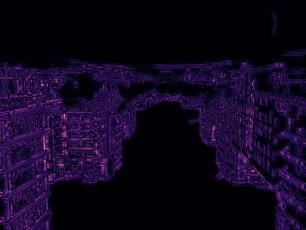

caption: This image represents an edge-detection visualization of a cityscape, likely highlighting the architectural outlines and structural features of buildings along a canal or street. The purple-toned outlines emphasize depth and contours against a dark background, illustrating a processed spatial representation of the urban scene. 

2607.28526v1_p7_i11  page=7  section=conclusion


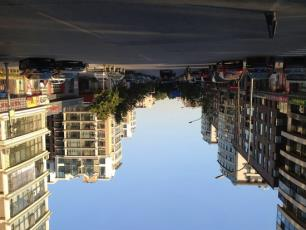

caption: This image shows an upside-down perspective of an urban street scene featuring multistory residential buildings and parked vehicles along the roadside. It provides a visual representation of a street canyon environment often used for studying urban spatial configurations or lighting conditions in computer vision research. 

2607.28526v1_p7_i12  page=7  section=conclusion


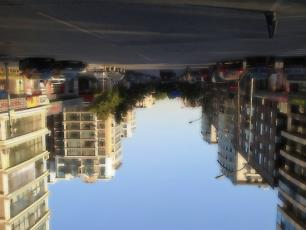

caption: This inverted street-level photograph depicts an urban scene with multi-story residential buildings flanking a roadway. The view captures the structural layout of the street corridor, showing the surrounding architectural facades and the empty road surface extending into the distance. 



In [14]:
# Do the captions actually describe the figures? This is the check that catches a broken image
# pipeline — a plausible-sounding caption for the wrong image looks fine in text alone.
#
# Only images that became chunks are displayed. NOT_A_FIGURE and caption failures are skipped
# because neither reaches the index. The counts are still printed: a rejection rate that drifts
# is the first sign the VLM prompt needs revisiting.
from IPython.display import Image, display

kept = [i for i in doc.images if i.caption and i.caption != "NOT_A_FIGURE"]
rejected = [i for i in doc.images if i.caption == "NOT_A_FIGURE"]
failed = [i for i in doc.images if i.caption is None]
print(f"{len(doc.images)} extracted -> {len(kept)} indexed, "
      f"{len(rejected)} NOT_A_FIGURE, {len(failed)} caption failed\n")

for img in kept:
    print(f"{img.image_id}  page={img.page}  section={img.section}")
    display(Image(data=img.image_bytes, format=img.ext))
    print("caption:", img.caption, "\n")


2607.28526v1_p7_i1  page=7  section=conclusion


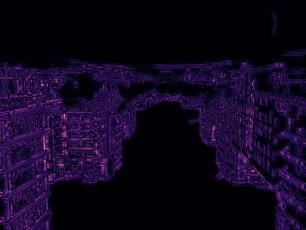

caption: This image represents an edge-detection visualization of a cityscape, likely highlighting the architectural outlines and structural features of buildings along a canal or street. The purple-toned outlines emphasize depth and contours against a dark background, illustrating a processed spatial representation of the urban scene. 

2607.28526v1_p7_i2  page=7  section=conclusion


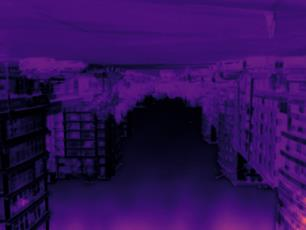

caption: NOT_A_FIGURE 

2607.28526v1_p7_i3  page=7  section=conclusion


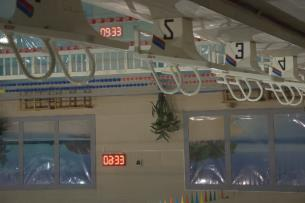

caption: NOT_A_FIGURE 

2607.28526v1_p7_i4  page=7  section=conclusion


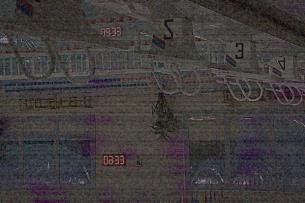

caption: NOT_A_FIGURE 

2607.28526v1_p7_i5  page=7  section=conclusion


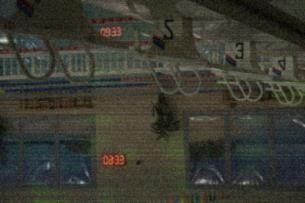

caption: NOT_A_FIGURE 

2607.28526v1_p7_i6  page=7  section=conclusion


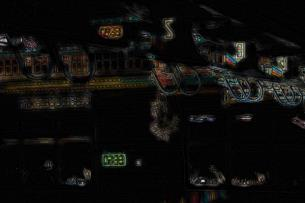

caption: NOT_A_FIGURE 

2607.28526v1_p7_i7  page=7  section=conclusion


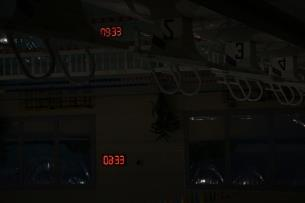

caption: NOT_A_FIGURE 

2607.28526v1_p7_i8  page=7  section=conclusion


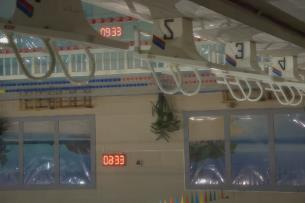

caption: NOT_A_FIGURE 

2607.28526v1_p7_i9  page=7  section=conclusion


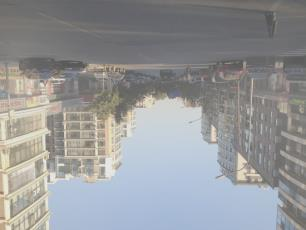

caption: NOT_A_FIGURE 

2607.28526v1_p7_i10  page=7  section=conclusion


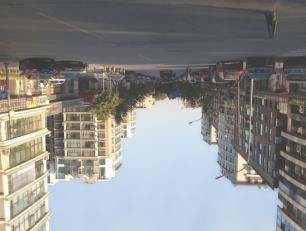

caption: NOT_A_FIGURE 

2607.28526v1_p7_i11  page=7  section=conclusion


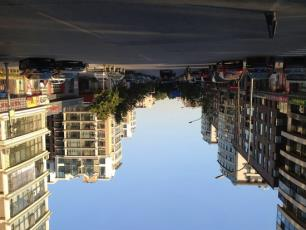

caption: This image shows an upside-down perspective of an urban street scene featuring multistory residential buildings and parked vehicles along the roadside. It provides a visual representation of a street canyon environment often used for studying urban spatial configurations or lighting conditions in computer vision research. 

2607.28526v1_p7_i12  page=7  section=conclusion


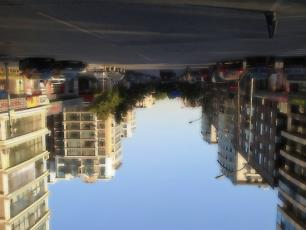

caption: This inverted street-level photograph depicts an urban scene with multi-story residential buildings flanking a roadway. The view captures the structural layout of the street corridor, showing the surrounding architectural facades and the empty road surface extending into the distance. 



In [15]:
# Do the captions actually describe the figures? This is the check that catches a broken image
# pipeline — a plausible-sounding caption for the wrong image looks fine in text alone.
from IPython.display import Image, display

for img in doc.images:
    print(f"{img.image_id}  page={img.page}  section={img.section}")
    display(Image(data=img.image_bytes, format=img.ext))
    print("caption:", img.caption, "\n")

## Batch mode

Only once the single-document output above looks right. Start small and watch for rate-limit errors
before scaling toward the full 100-document Phase 1 slice.

In [ ]:
import collections

# Expanded 2026-08-19 from ai-only to ai + cs.CL + finance (unblocks Phase 5's router/fanout,
# which need more than one real category to be anything but degenerate). Per the docstring on
# save_extractions() below: re-run this cell over the union of paths and save again - chunk IDs
# are deterministic, so anything unchanged upserts over itself.
CATEGORIES = ["ai", "cs.CL", "finance"]

# Some arXiv papers are cross-listed and were downloaded into more than one category folder
# (found while expanding: 6 duplicated across ai/cs.CL, 1 across ai/hep-th - byte-identical
# files, confirmed by MD5). A paper can only have one ground-truth category for the router, so
# first-seen-in-CATEGORIES-order wins and later duplicates are dropped, not silently re-indexed
# under a second category.
sample_paths = []
seen_arxiv_ids: dict[str, str] = {}
skipped_dupes = []
for cat in CATEGORIES:
    for pdf_path in sorted((PAPERS_DIR / cat).glob("*.pdf")):
        arxiv_id = pdf_path.stem
        if arxiv_id in seen_arxiv_ids:
            skipped_dupes.append((arxiv_id, cat, seen_arxiv_ids[arxiv_id]))
            continue
        seen_arxiv_ids[arxiv_id] = cat
        sample_paths.append(pdf_path)

if skipped_dupes:
    print(f"skipped {len(skipped_dupes)} cross-listed duplicate(s):")
    for arxiv_id, dupe_cat, kept_cat in skipped_dupes:
        print(f"  {arxiv_id}: kept under <{kept_cat}>, skipped duplicate under <{dupe_cat}>")

batch = process_documents_batch(sample_paths, vlm=llm, section_llm=llm, max_workers=3)

for r in batch:
    print(r.summary())

n = max(len(batch), 1)
sources = collections.Counter(r.section_source for r in batch)
print(f"
section_source distribution: {dict(sources)}")
print(f"  toc (bookmarks) : {sources['toc'] / n:.0%}")
print(f"  font rules      : {sources['headings'] / n:.0%}")
print(f"  rescued by LLM  : {sources['llm'] / n:.0%}")
print(f"  page fallback   : {sources['page_fallback'] / n:.0%}   <- still unresolved")
print("topic_source distribution:", dict(collections.Counter(r.topic_source for r in batch)))
print("category distribution    :", dict(collections.Counter(r.category for r in batch)))
print("figures captioned:", sum(1 for r in batch for i in r.images if i.caption))
print("total chunks:", sum(len(r.chunks) for r in batch))

# How many papers even have bookmarks? Determines whether the outline is a primary strategy
# for this corpus or an occasional bonus.
with_toc = sum(1 for p in sample_paths if document_toc(p))
print(f"
papers with a PDF outline: {with_toc}/{len(sample_paths)}")


In [38]:
# failed = [r for r in batch if not r.sections_found]

# print(f"{len(failed)}/{len(batch)} fell back to the page-count heuristic\n")
# for r in failed:
#     print(f"  {r.arxiv_id} <{r.category}> {r.num_pages}p  topic: {r.topic[:70] or '(none)'}")

## Persist — the ingestion / retrieval hand-off

Ingestion ends here. Everything after this notebook — embedding, Qdrant, retrieval, eval —
reads `data/phase1/`, never this kernel.


In [39]:
# --- Persistence: the hand-off boundary between ingestion and everything downstream -------
#
# Ingestion is the expensive, non-deterministic half of the pipeline: parsing takes minutes and
# figure captioning costs real money on every run. Every phase after this one - embedding,
# retrieval, eval, the agent graph - needs the *same* chunks, repeatedly. So the extraction is
# written to disk once and read from disk forever after. Nothing downstream is allowed to
# depend on this notebook's kernel still being alive.
#
# data/phase1/
#   chunks.jsonl                        one line per chunk  -> the embedding input
#   documents.jsonl                     one line per paper  -> telemetry (section 7) + manifests
#   images/<arxiv_id>/<image_id>.<ext>  raw bytes
#
# Image bytes stay as files rather than base64 in the JSONL: they would bloat the embedding
# input ~4x with data retrieval never touches. Retrieval matches the VLM *caption*; the original
# image is loaded by path at generation time, resolved from the chunk's figure_ref (ROADMAP 1).

import uuid

DATA_DIR = PROJECT_ROOT / "data" / "phase1"
CHUNKS_PATH = DATA_DIR / "chunks.jsonl"
DOCS_PATH = DATA_DIR / "documents.jsonl"
IMAGES_DIR = DATA_DIR / "images"

# Qdrant point IDs must be an unsigned int or a UUID - an arbitrary string is rejected. A UUIDv5
# over stable content gives a deterministic ID, which is what turns re-ingestion into an
# idempotent upsert instead of a duplicate insert (ROADMAP Phase 2). Chunk *text* is deliberately
# not part of the key: when a re-parse shifts a boundary by a word, that chunk should be
# overwritten, not silently duplicated alongside its own previous version.
CHUNK_ID_NAMESPACE = uuid.UUID("6f2b1e0c-0c1a-4c8e-9a6e-1f3f5c2d7a10")

# One payload schema for every chunk, regardless of modality. build_chunks() only sets `page` on
# figures and tables, so text chunks would otherwise arrive with the key absent - and in Qdrant a
# missing key and a null key behave differently under a filter. Text chunks legitimately have no
# single page (a chunk spans whatever pages its section covers), so the value is null and the
# key is always present.
PAYLOAD_FIELDS = (
    "arxiv_id", "category", "topic", "section", "modality", "page", "figure_ref", "section_source",
)


def chunk_id(arxiv_id: str, ordinal: int, modality: str, figure_ref: str | None) -> str:
    return str(uuid.uuid5(CHUNK_ID_NAMESPACE, f"{arxiv_id}|{ordinal}|{modality}|{figure_ref or ''}"))


def save_extractions(docs: list[DocumentExtraction], data_dir: Path = DATA_DIR) -> dict:
    """Write chunks, document telemetry and image bytes to `data_dir`.

    Rewrites both JSONL files from `docs` in full rather than appending, so running this twice
    on the same batch cannot double the corpus. To add categories later, re-run the batch cell
    over the union of paths and save again - the chunk IDs are deterministic, so anything
    unchanged keeps the ID it had and upserts over itself in Qdrant.
    """
    data_dir.mkdir(parents=True, exist_ok=True)
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)

    stats = {"documents": 0, "chunks": 0, "images_written": 0, "images_chunked": 0, "tables": 0}
    seen_ids: set[str] = set()

    with (
        open(data_dir / "chunks.jsonl", "w", encoding="utf-8") as f_chunks,
        open(data_dir / "documents.jsonl", "w", encoding="utf-8") as f_docs,
    ):
        for doc in docs:
            stats["documents"] += 1

            for ordinal, chunk in enumerate(doc.chunks):
                md = chunk.metadata
                payload = {field: md.get(field) for field in PAYLOAD_FIELDS}
                cid = chunk_id(doc.arxiv_id, ordinal, payload["modality"], payload["figure_ref"])
                # A collision here would mean two chunks silently overwriting each other in
                # Qdrant - exactly the class of silent loss section 9 is about. Fail loudly.
                if cid in seen_ids:
                    raise ValueError(f"duplicate chunk id {cid} ({doc.arxiv_id} ordinal={ordinal})")
                seen_ids.add(cid)
                f_chunks.write(json.dumps(
                    {"id": cid, "ordinal": ordinal, "text": chunk.page_content, **payload},
                    ensure_ascii=False,
                ) + "\n")
                stats["chunks"] += 1

            image_records = []
            doc_img_dir = IMAGES_DIR / doc.arxiv_id
            for img in doc.images:
                doc_img_dir.mkdir(parents=True, exist_ok=True)
                path = doc_img_dir / f"{img.image_id}.{img.ext}"
                path.write_bytes(img.image_bytes)
                stats["images_written"] += 1
                # Captioned but unusable (NOT_A_FIGURE) and captioning-failed (None) are kept and
                # distinguished. build_chunks drops both, so without this record the section 7
                # "figures extracted vs captioned vs indexed" numbers cannot be reconstructed.
                indexed = bool(img.caption) and img.caption != "NOT_A_FIGURE"
                stats["images_chunked"] += indexed
                image_records.append({
                    "image_id": img.image_id,
                    "page": img.page,
                    "section": img.section,
                    "ext": img.ext,
                    "path": str(path.relative_to(data_dir)).replace("\\", "/"),
                    "caption": img.caption,
                    "indexed": indexed,
                })

            stats["tables"] += len(doc.tables)
            f_docs.write(json.dumps({
                "arxiv_id": doc.arxiv_id,
                "category": doc.category,
                "topic": doc.topic,
                "topic_source": doc.topic_source,
                "num_pages": doc.num_pages,
                # JSON object keys are strings, so the int author positions come back as "0","1".
                "authors": {str(k): v for k, v in doc.authors.items()},
                "section_source": doc.section_source,
                "sections_found": doc.sections_found,
                "n_chunks": len(doc.chunks),
                "by_modality": dict(collections.Counter(c.metadata["modality"] for c in doc.chunks)),
                "images": image_records,
                # The markdown itself is already a chunk; this is the detected-vs-rendered ledger.
                "tables": [{"table_id": t["table_id"], "page": t["page"], "section": t["section"]}
                           for t in doc.tables],
            }, ensure_ascii=False) + "\n")

    return stats


stats = save_extractions(batch)
print(f"wrote {DATA_DIR}")
print(stats)
print(f"  figures: {stats['images_written']} extracted -> {stats['images_chunked']} indexed "
      f"({stats['images_written'] - stats['images_chunked']} NOT_A_FIGURE or caption failure)")

wrote d:\.tutorials\agentic-rag-capstone\data\phase1
{'documents': 20, 'chunks': 544, 'images_written': 72, 'images_chunked': 16, 'tables': 7}
  figures: 72 extracted -> 16 indexed (56 NOT_A_FIGURE or caption failure)


In [40]:
# Read the files back and check them against the in-memory batch. Serialisation is exactly the
# kind of step that "succeeds" while dropping a modality (section 9), and it is the last point at
# which the source objects are still around to compare against - after this kernel dies, a
# missing figure chunk is indistinguishable from a figure that never existed.
reloaded = [json.loads(line) for line in CHUNKS_PATH.read_text(encoding="utf-8").splitlines()]
reloaded_docs = [json.loads(line) for line in DOCS_PATH.read_text(encoding="utf-8").splitlines()]

in_memory = collections.Counter(c.metadata["modality"] for r in batch for c in r.chunks)
on_disk = collections.Counter(c["modality"] for c in reloaded)
assert in_memory == on_disk, f"modality mismatch: memory={in_memory} disk={on_disk}"
assert len({c["id"] for c in reloaded}) == len(reloaded), "chunk IDs are not unique"
assert all(c["text"].strip() for c in reloaded), "empty chunk text reached disk"
assert all(set(c) >= set(PAYLOAD_FIELDS) for c in reloaded), "payload schema is ragged"

missing = [i["path"] for d in reloaded_docs for i in d["images"] if not (DATA_DIR / i["path"]).exists()]
assert not missing, f"{len(missing)} image files referenced but not written"

print(f"{len(reloaded_docs)} documents, {len(reloaded)} chunks, modality {dict(on_disk)}")
print("category       :", dict(collections.Counter(c["category"] for c in reloaded)))
print("section        :", dict(collections.Counter(c["section"] for c in reloaded)))
print("section_source :", dict(collections.Counter(c["section_source"] for c in reloaded)))

lengths = sorted(len(c["text"]) for c in reloaded)
print(f"chunk chars    : min={lengths[0]} median={lengths[len(lengths) // 2]} max={lengths[-1]}")
# Tables and captions are single chunks by design (section 5) and bypass the splitter, so they are
# the only things that can exceed CHUNK_SIZE. Anything long here is a truncation risk once the
# embedder's token limit applies - the embed notebook audits that directly.
oversized = [c for c in reloaded if len(c["text"]) > CHUNK_SIZE]
print(f"over CHUNK_SIZE: {len(oversized)} "
      f"{dict(collections.Counter(c['modality'] for c in oversized))}")

20 documents, 544 chunks, modality {'text': 521, 'figure': 16, 'table': 7}
category       : {'ai': 544}
section        : {'abstract_intro': 158, 'conclusion': 386}
section_source : {'headings': 32, 'toc': 512}
chunk chars    : min=151 median=956 max=999
over CHUNK_SIZE: 0 {}
